# Selección de características en `data_model`
En esta notebook realizamos feature selection con dos técnicas sin etiqueta y dos técnicas con etiqueta, usando `Type` como label.

- Sin label: Variance Threshold y Laplacian Score.
- Con label: ANOVA F-test y Mutual Information.
- El objetivo es comparar los conjuntos de características sugeridos por cada método y preparar un listado para modelado.

In [1]:
# Importar librerías y cargar el dataset data_model
import os
import pandas as pd
import numpy as np

from sklearn.feature_selection import VarianceThreshold, f_classif, mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler

path = os.path.join(r'c:\Users\ricar\OneDrive\Desktop\TESIS', 'data_model.csv')
if os.path.exists(path):
    data_model = pd.read_csv(path)
else:
    raise FileNotFoundError(f'No se encontró data_model.csv en {path}')

print('data_model shape:', data_model.shape)
print('\nConteo por Type:')
print(data_model['Type'].value_counts())
print('\nPrimeras filas:')
print(data_model.head())

data_model shape: (23779, 85)

Conteo por Type:
Type
LP       12597
VT        8857
TREMI      712
VLP        548
HB         541
TRE        252
TRESP      185
EXPL        87
Name: count, dtype: int64

Primeras filas:
   Type  f_90_percent_energy  f_PeaksAboveRMSDensity_fun   f_energy  \
0  EXPL             7.812500                    0.064327  88.667131   
1  EXPL             7.080078                    0.046784  89.716010   
2  EXPL             9.960938                    0.027290  86.073468   
3  EXPL             7.666016                    0.050682  54.215575   
4  EXPL             9.228516                    0.044834  95.018260   

      f_entropy  f_kurtosis     f_mean  f_multiscaleEntropy  f_peak2rms  \
0 -6.668203e+06    2.335528 -38.546551             2.105047    8.962248   
1 -7.224606e+06    1.937270 -40.262434             2.169781   10.486386   
2 -6.918588e+06    3.035101 -38.394380             1.971289   20.620064   
3 -7.645442e+06    2.024171 -41.384352             2.1562

In [2]:
# Preparar X e y
label_col = 'Type'
feature_cols = [c for c in data_model.columns if c != label_col and data_model[c].dtype != 'O']

X = data_model[feature_cols].copy()
y = data_model[label_col].copy()

print('Número de features numéricos:', len(feature_cols))
print('Columns sample:', feature_cols[:10])

if X.isna().any().any():
    X = X.fillna(X.median())
    print('\nSe imputaron nulos con la mediana de cada columna.')

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('\nLabel encoding aplicado a Type. Clases:', list(le.classes_))

Número de features numéricos: 84
Columns sample: ['f_90_percent_energy', 'f_PeaksAboveRMSDensity_fun', 'f_energy', 'f_entropy', 'f_kurtosis', 'f_mean', 'f_multiscaleEntropy', 'f_peak2rms', 'f_peak_1020_pos', 'f_peak_1020_value']

Label encoding aplicado a Type. Clases: ['EXPL', 'HB', 'LP', 'TRE', 'TREMI', 'TRESP', 'VLP', 'VT']


In [3]:
# 1) Selección sin label: Variance Threshold
var_thresh = VarianceThreshold(threshold=0.01)
var_mask = var_thresh.fit(X_scaled).get_support()
selected_variance = [col for col, keep in zip(feature_cols, var_mask) if keep]
print('Features retenidas por VarianceThreshold:', len(selected_variance))
print(selected_variance[:30])

Features retenidas por VarianceThreshold: 84
['f_90_percent_energy', 'f_PeaksAboveRMSDensity_fun', 'f_energy', 'f_entropy', 'f_kurtosis', 'f_mean', 'f_multiscaleEntropy', 'f_peak2rms', 'f_peak_1020_pos', 'f_peak_1020_value', 'f_peak_2030_pos', 'f_peak_2030_value', 'f_peaks_pos_1', 'f_peaks_pos_2', 'f_peaks_pos_3', 'f_peaks_val_2', 'f_peaks_val_3', 'f_power', 'f_rms', 'f_std', 'f_var', 't_PeaksAboveRMSDensity_fun', 't_energy', 't_entropy', 't_kurtosis', 't_mean', 't_multiscaleEntropy', 't_peak2peak', 't_peak2rms', 't_rms']


In [4]:
# 2) Selección sin label: Laplacian Score
from sklearn.metrics.pairwise import rbf_kernel

X_for_graph = X_scaled.values
W = rbf_kernel(X_for_graph, gamma=1.0 / X_for_graph.shape[1])
D = np.diag(W.sum(axis=1))
L = D - W

scores = []
for i, col in enumerate(feature_cols):
    f = X_for_graph[:, i]
    f_mean = np.mean(f)
    f_centered = f - f_mean
    numerator = f_centered.T.dot(L).dot(f_centered)
    denominator = f_centered.T.dot(D).dot(f_centered)
    score = numerator / (denominator + 1e-12)
    scores.append((col, score))

laplacian_scores = sorted(scores, key=lambda x: x[1])
selected_laplacian = [col for col, _ in laplacian_scores[:30]]
print('Primeras 30 features por Laplacian Score (mejor menor):')
print(selected_laplacian)

laplacian_df = pd.DataFrame(laplacian_scores, columns=['feature', 'score'])
print('\nTop 10 Laplacian Score:')
print(laplacian_df.head(10))

Primeras 30 features por Laplacian Score (mejor menor):
['f_power', 'w_t_meanEnergyCoeff', 'w_t_meanEnergyAD', 'w_t_rms_A6', 't_rms', 'f_energy', 't_energy', 'w_t_peak2rms_A6', 'f_entropy', 't_peak2peak', 'w_f_maxpos_D2', 'w_f_maxpos_A6', 'w_f_maxval_D3', 'w_f_maxval_A6', 'w_t_PEC_A6', 'f_var', 't_peak2rms', 'w_t_PEC_D3', 'f_rms', 'f_mean', 'w_f_mean_A6', 'w_t_rms_D3', 'w_t_peak2peak_D3', 'w_f_maxval_D2', 't_zcr', 'f_std', 'f_90_percent_energy', 'w_t_PEC_D2', 'w_t_PEC_D5', 't_multiscaleEntropy']

Top 10 Laplacian Score:
               feature     score
0              f_power  0.660251
1  w_t_meanEnergyCoeff  0.661795
2     w_t_meanEnergyAD  0.665112
3           w_t_rms_A6  0.679607
4                t_rms  0.683437
5             f_energy  0.703970
6             t_energy  0.703970
7      w_t_peak2rms_A6  0.705995
8            f_entropy  0.715214
9          t_peak2peak  0.717770


In [6]:
# 3) Selección con label: ANOVA F-test
f_values, p_values = f_classif(X_scaled, y_encoded)
feature_anova = pd.DataFrame({'feature': feature_cols, 'F_value': f_values, 'p_value': p_values})
feature_anova = feature_anova.sort_values(by='F_value', ascending=False).reset_index(drop=True)
selected_anova = feature_anova['feature'].tolist()[:30]
print('Top 30 features por ANOVA F-test:')
print(selected_anova)
print('\nANOVA top 10:')
print(feature_anova.head(10))

Top 30 features por ANOVA F-test:
['w_t_PEC_A6', 'w_t_PEC_D3', 'w_t_rms_D3', 'w_t_peak2peak_D3', 'w_t_rms_A6', 'w_f_mean_A6', 'w_f_maxval_D3', 'w_t_peak2rms_D6', 'f_std', 't_peak2rms', 't_rms', 't_time2peak', 't_entropy', 't_peak2peak', 'f_peak_2030_value', 'f_rms', 'w_t_meanEnergyCoeff', 'f_peaks_pos_1', 't_multiscaleEntropy', 'w_t_peak2peak_A6', 'f_mean', 'w_f_maxval_A6', 'f_kurtosis', 'w_t_rms_D1', 'f_var', 'w_f_mean_D1', 'w_f_maxval_D1', 'f_entropy', 'f_peak_1020_value', 'f_peak2rms']

ANOVA top 10:
            feature      F_value  p_value
0        w_t_PEC_A6  1478.555960      0.0
1        w_t_PEC_D3  1454.047862      0.0
2        w_t_rms_D3  1407.035411      0.0
3  w_t_peak2peak_D3  1215.367863      0.0
4        w_t_rms_A6  1200.018062      0.0
5       w_f_mean_A6  1055.470309      0.0
6     w_f_maxval_D3   935.732359      0.0
7   w_t_peak2rms_D6   933.940734      0.0
8             f_std   918.617726      0.0
9        t_peak2rms   883.178311      0.0


In [7]:
# 4) Selección con label: Mutual Information
mi_scores = mutual_info_classif(X_scaled, y_encoded, discrete_features=False, random_state=42)
feature_mi = pd.DataFrame({'feature': feature_cols, 'mi_score': mi_scores})
feature_mi = feature_mi.sort_values(by='mi_score', ascending=False).reset_index(drop=True)
selected_mi = feature_mi['feature'].tolist()[:30]
print('Top 30 features por Mutual Information:')
print(selected_mi)
print('\nMutual Information top 10:')
print(feature_mi.head(10))

Top 30 features por Mutual Information:
['f_peaks_pos_1', 'w_t_PEC_D3', 'f_std', 'f_var', 'w_t_rms_D3', 'f_entropy', 'f_peaks_pos_2', 'f_rms', 't_mean', 'w_t_PEC_A6', 'f_90_percent_energy', 't_PeaksAboveRMSDensity_fun', 'w_t_rms_A6', 'w_f_mean_A6', 'w_t_meanEnergyCoeff', 't_time2peak', 'w_t_peak2peak_D3', 'f_mean', 'w_t_PEC_D5', 't_rms', 't_peak2rms', 'w_f_maxval_D3', 'w_f_maxval_D5', 'w_t_rms_D5', 'w_t_PEC_D4', 't_entropy', 'w_f_maxval_A6', 'f_peaks_pos_3', 'w_t_meanEnergyAD', 'w_t_peak2peak_D5']

Mutual Information top 10:
         feature  mi_score
0  f_peaks_pos_1  0.261085
1     w_t_PEC_D3  0.208260
2          f_std  0.199076
3          f_var  0.199050
4     w_t_rms_D3  0.186852
5      f_entropy  0.183567
6  f_peaks_pos_2  0.181604
7          f_rms  0.179636
8         t_mean  0.178019
9     w_t_PEC_A6  0.177903


In [10]:
# Comparación de los resultados y guardado de listados
results = {
    'VarianceThreshold': selected_variance,
    'LaplacianScore': selected_laplacian,
    'ANOVA_F_test': selected_anova,
    'MutualInformation': selected_mi,
}

for method, features in results.items():
    print(f'{method}: {len(features)} features, primeros 10 -> {features[:10]}')

output_dir = os.path.join(r'c:\Users\ricar\OneDrive\Desktop\TESIS')
for method, features in results.items():
    out_path = os.path.join(output_dir, f'{method}_selected_features.txt')
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(features))
    print(f'Guardado {method} en {out_path}')

# Borda voting para ranking consensuado de características
all_features = feature_cols
n_features = len(all_features)

method_rankings = {}
method_rankings['VarianceThreshold'] = pd.Series(X_scaled.var(ddof=0), index=all_features).sort_values(ascending=False)
method_rankings['LaplacianScore'] = pd.Series({col: score for col, score in laplacian_scores}).sort_values(ascending=True)
method_rankings['ANOVA_F_test'] = feature_anova.set_index('feature')['F_value'].sort_values(ascending=False)
method_rankings['MutualInformation'] = feature_mi.set_index('feature')['mi_score'].sort_values(ascending=False)

borda_scores = pd.Series(0, index=all_features, dtype=float)
for method, ranked_series in method_rankings.items():
    rank_positions = {feature: pos + 1 for pos, feature in enumerate(ranked_series.index)}
    borda_scores += pd.Series({feature: n_features - rank_positions.get(feature, n_features) for feature in all_features})

borda_ranking = borda_scores.sort_values(ascending=False).reset_index()
borda_ranking.columns = ['feature', 'borda_score']
print('\nTop 30 features por Borda voting:')
print(borda_ranking.head(30))

borda_path = os.path.join(output_dir, 'borda_feature_ranking.csv')
borda_ranking.to_csv(borda_path, index=False)
print(f'Guardado ranking Borda en {borda_path}')

with open(os.path.join(output_dir, 'borda_feature_ranking.txt'), 'w', encoding='utf-8') as f:
    for feature, score in borda_ranking.itertuples(index=False):
        f.write(f'{feature}\t{score}\n')
print('Guardado Borda ranking en borda_feature_ranking.txt')

VarianceThreshold: 84 features, primeros 10 -> ['f_90_percent_energy', 'f_PeaksAboveRMSDensity_fun', 'f_energy', 'f_entropy', 'f_kurtosis', 'f_mean', 'f_multiscaleEntropy', 'f_peak2rms', 'f_peak_1020_pos', 'f_peak_1020_value']
LaplacianScore: 30 features, primeros 10 -> ['f_power', 'w_t_meanEnergyCoeff', 'w_t_meanEnergyAD', 'w_t_rms_A6', 't_rms', 'f_energy', 't_energy', 'w_t_peak2rms_A6', 'f_entropy', 't_peak2peak']
ANOVA_F_test: 30 features, primeros 10 -> ['w_t_PEC_A6', 'w_t_PEC_D3', 'w_t_rms_D3', 'w_t_peak2peak_D3', 'w_t_rms_A6', 'w_f_mean_A6', 'w_f_maxval_D3', 'w_t_peak2rms_D6', 'f_std', 't_peak2rms']
MutualInformation: 30 features, primeros 10 -> ['f_peaks_pos_1', 'w_t_PEC_D3', 'f_std', 'f_var', 'w_t_rms_D3', 'f_entropy', 'f_peaks_pos_2', 'f_rms', 't_mean', 'w_t_PEC_A6']
Guardado VarianceThreshold en c:\Users\ricar\OneDrive\Desktop\TESIS\VarianceThreshold_selected_features.txt
Guardado LaplacianScore en c:\Users\ricar\OneDrive\Desktop\TESIS\LaplacianScore_selected_features.txt
Gua

C:\Users\ricar\AppData\Local\Temp\ipykernel_6116\1550603313.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='feature', y='borda_score', palette='magma')
C:\Users\ricar\AppData\Local\Temp\ipykernel_6116\1550603313.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')


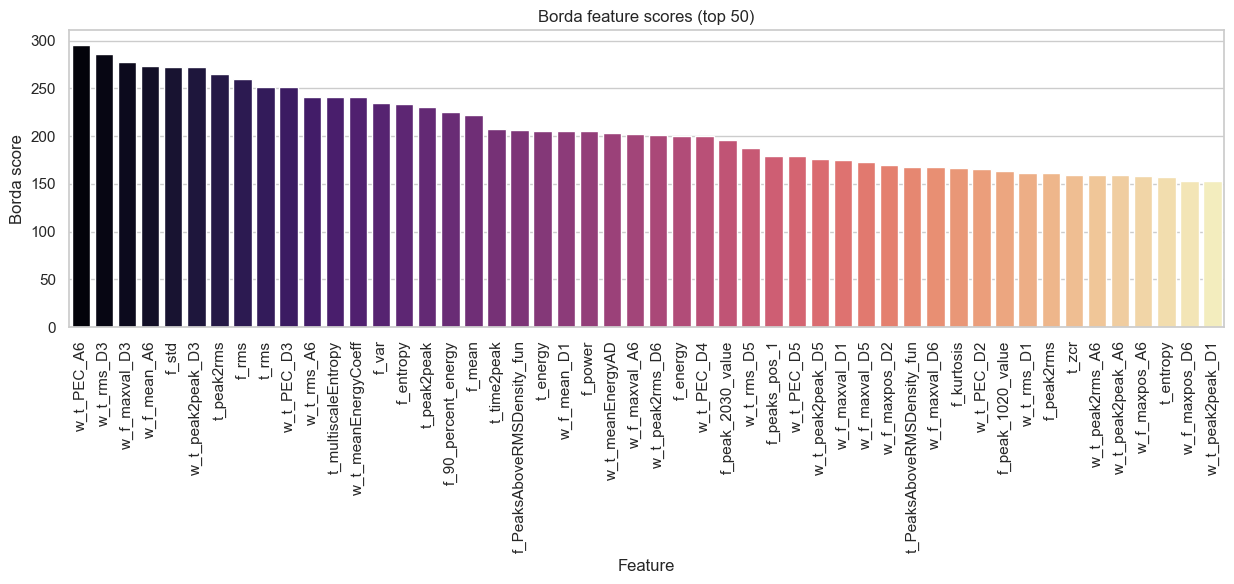

In [11]:
# Gráfica del Borda score (eje x = feature, eje y = borda_score)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# Mostrar top N para evitar solapamiento de etiquetas
top_n = 50
plot_df = borda_ranking.copy().head(top_n)

plt.figure(figsize=(max(12, len(plot_df)*0.25), 6))
ax = sns.barplot(data=plot_df, x='feature', y='borda_score', palette='magma')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
plt.xlabel('Feature')
plt.ylabel('Borda score')
plt.title(f'Borda feature scores (top {top_n})')
plt.tight_layout()
plt.show()

C:\Users\ricar\AppData\Local\Temp\ipykernel_6116\1890809388.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=var_df, x='feature', y='score', ax=axes[0,0], palette='viridis')
C:\Users\ricar\AppData\Local\Temp\ipykernel_6116\1890809388.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lap_df_plot, x='feature', y='score', ax=axes[0,1], palette='magma')
C:\Users\ricar\AppData\Local\Temp\ipykernel_6116\1890809388.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=anova_df_plot, x='feature', y='score', ax=axes[1,0], palette

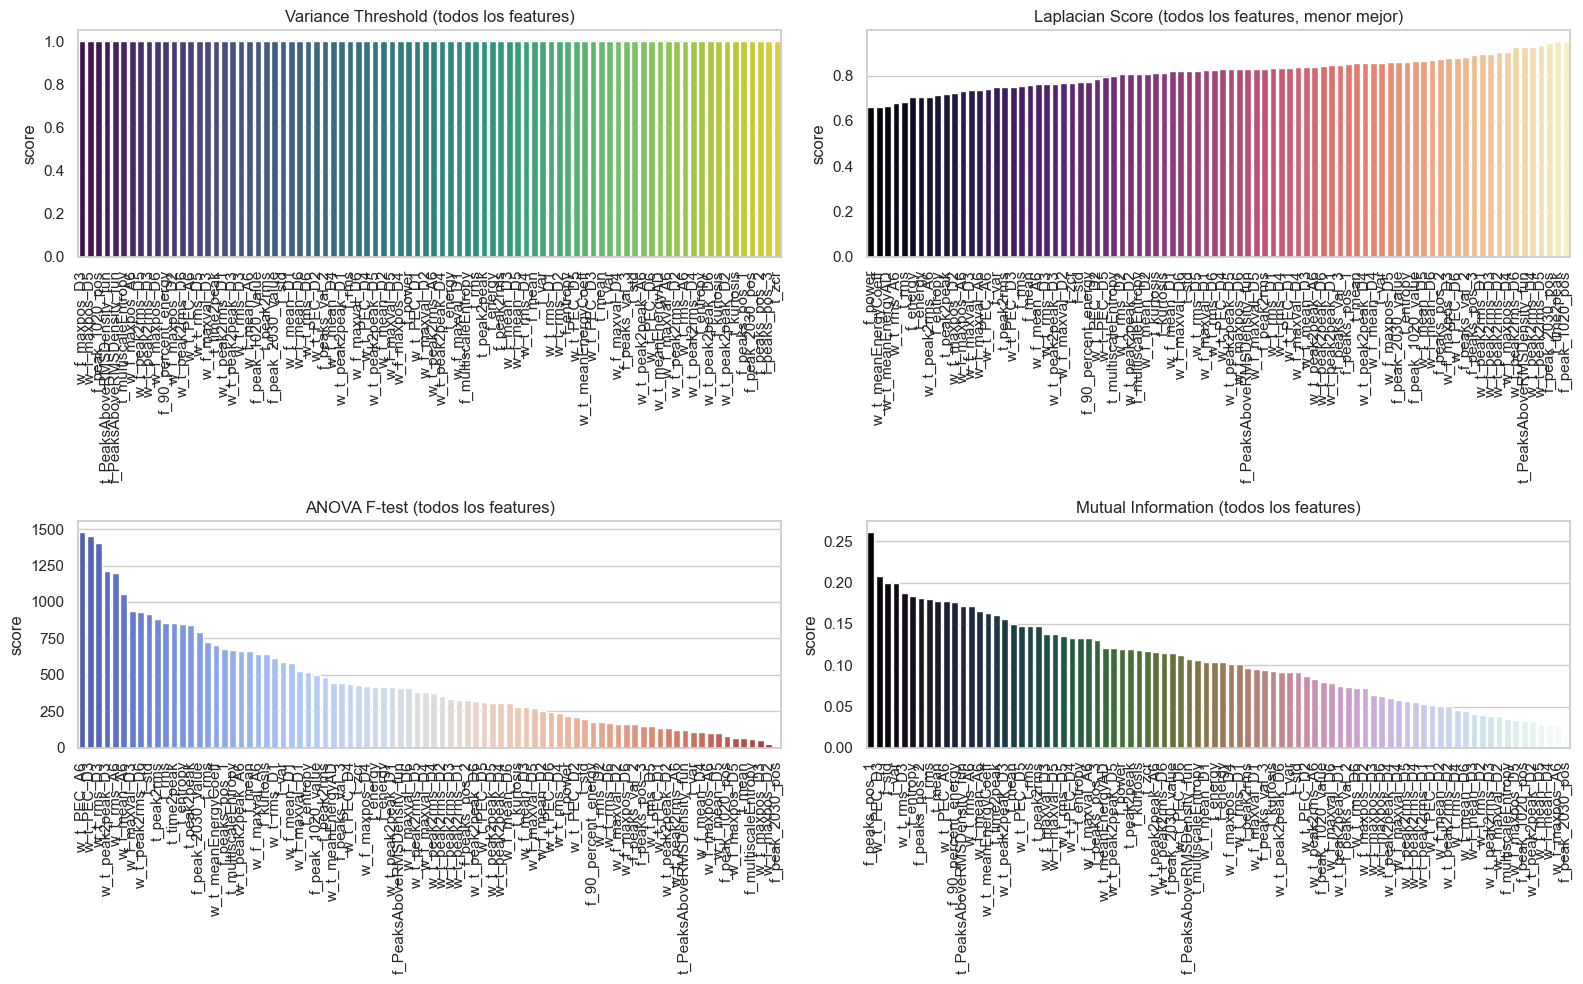

In [16]:
# Plots por método: eje x = feature, eje y = score (mostrar todos los features)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# Variance (mayor mejor) - todos los features
var_df = X_scaled.var(ddof=0).sort_values(ascending=False).reset_index()
var_df.columns = ['feature', 'score']
# Laplacian (menor mejor) - ordenamos ascendente pero mostraremos en ese orden
lap_df_plot = laplacian_df.sort_values('score', ascending=True).reset_index(drop=True).reset_index()
lap_df_plot.columns = ['rank', 'feature', 'score']
# ANOVA (mayor mejor)
anova_df_plot = feature_anova.sort_values('F_value', ascending=False).reset_index(drop=True)[['feature','F_value']]
anova_df_plot.columns = ['feature', 'score']
# Mutual Information (mayor mejor)
mi_df_plot = feature_mi.sort_values('mi_score', ascending=False).reset_index(drop=True)[['feature','mi_score']]
mi_df_plot.columns = ['feature', 'score']

# Número de features por gráfico
n_var = len(var_df)
n_lap = len(lap_df_plot)
n_anova = len(anova_df_plot)
n_mi = len(mi_df_plot)

# Ajustar figura según el número mayor de features
max_n = max(n_var, n_lap, n_anova, n_mi)
fig_w = max(16, int(max_n * 0.12))
fig, axes = plt.subplots(2, 2, figsize=(fig_w, 10))

# Variance
sns.barplot(data=var_df, x='feature', y='score', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Variance Threshold (todos los features)')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=90)

# Laplacian
# mostrar en el orden ascendente (mejor a la izquierda)
sns.barplot(data=lap_df_plot, x='feature', y='score', ax=axes[0,1], palette='magma')
axes[0,1].set_title('Laplacian Score (todos los features, menor mejor)')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=90)

# ANOVA
sns.barplot(data=anova_df_plot, x='feature', y='score', ax=axes[1,0], palette='coolwarm')
axes[1,0].set_title('ANOVA F-test (todos los features)')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=90)

# Mutual Information
sns.barplot(data=mi_df_plot, x='feature', y='score', ax=axes[1,1], palette='cubehelix')
axes[1,1].set_title('Mutual Information (todos los features)')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

C:\Users\ricar\AppData\Local\Temp\ipykernel_6116\1706119852.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='feature', y='cum_score', palette='viridis')
C:\Users\ricar\AppData\Local\Temp\ipykernel_6116\1706119852.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')


Guardado figura: c:\Users\ricar\OneDrive\Desktop\TESIS\Variance_cumulative_score.png


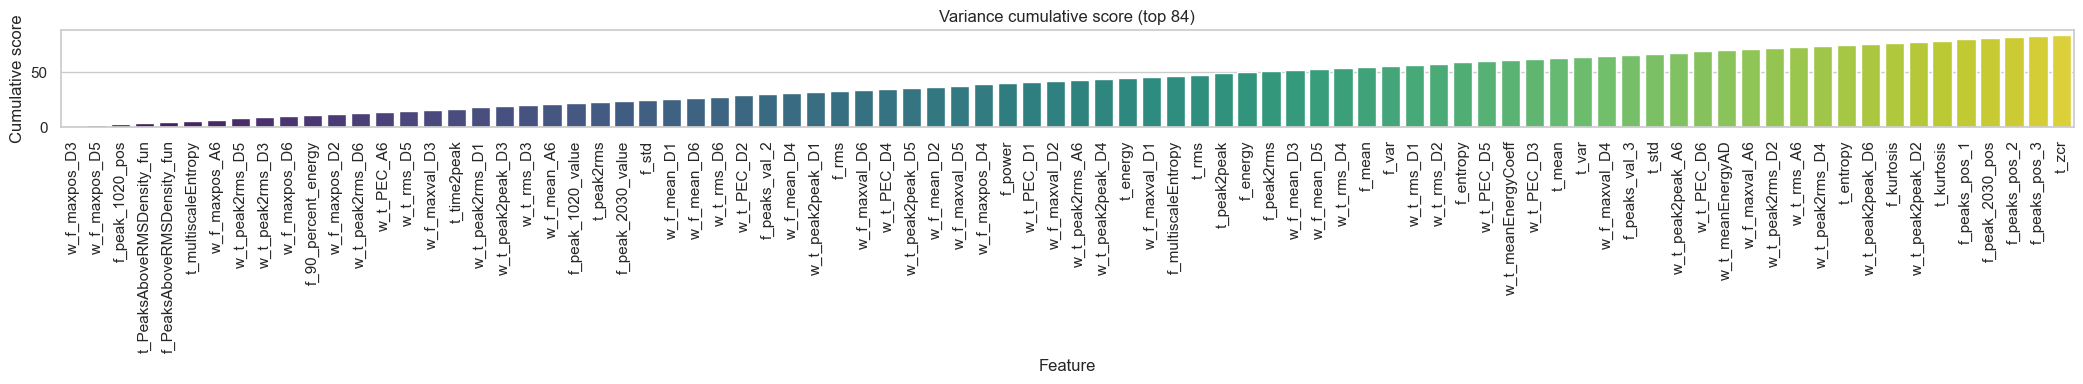

C:\Users\ricar\AppData\Local\Temp\ipykernel_6116\1706119852.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='feature', y='cum_score', palette='viridis')
C:\Users\ricar\AppData\Local\Temp\ipykernel_6116\1706119852.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')


Guardado figura: c:\Users\ricar\OneDrive\Desktop\TESIS\Laplacian_cumulative_score.png


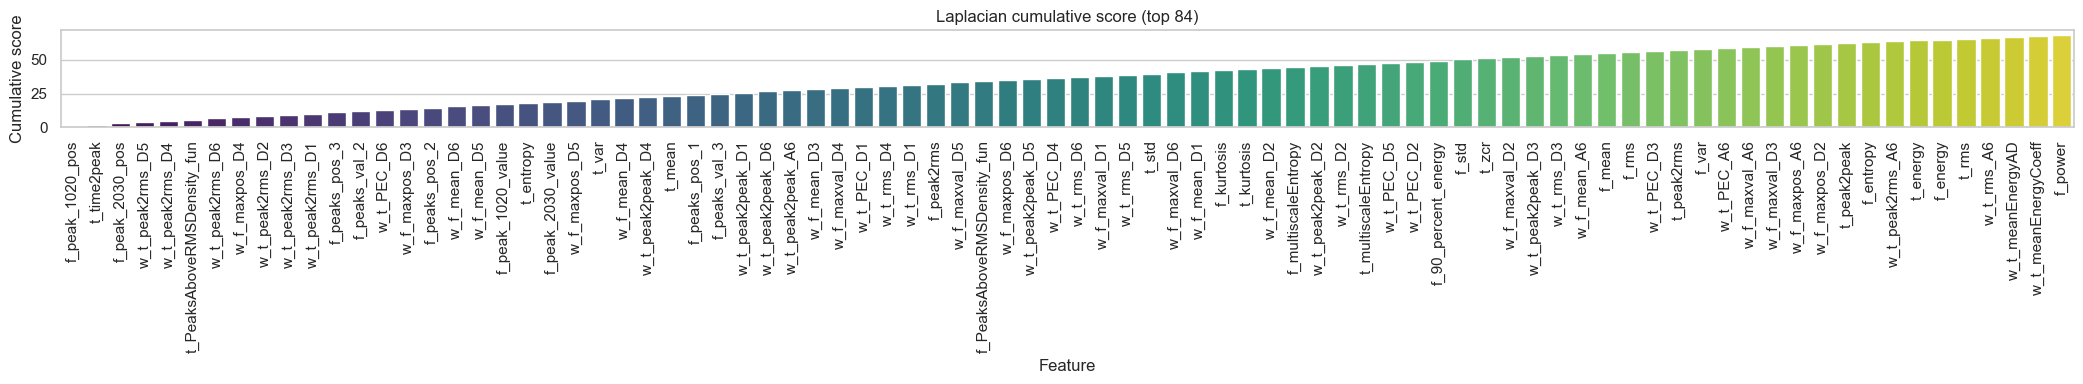

C:\Users\ricar\AppData\Local\Temp\ipykernel_6116\1706119852.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='feature', y='cum_score', palette='viridis')
C:\Users\ricar\AppData\Local\Temp\ipykernel_6116\1706119852.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')


Guardado figura: c:\Users\ricar\OneDrive\Desktop\TESIS\ANOVA_cumulative_score.png


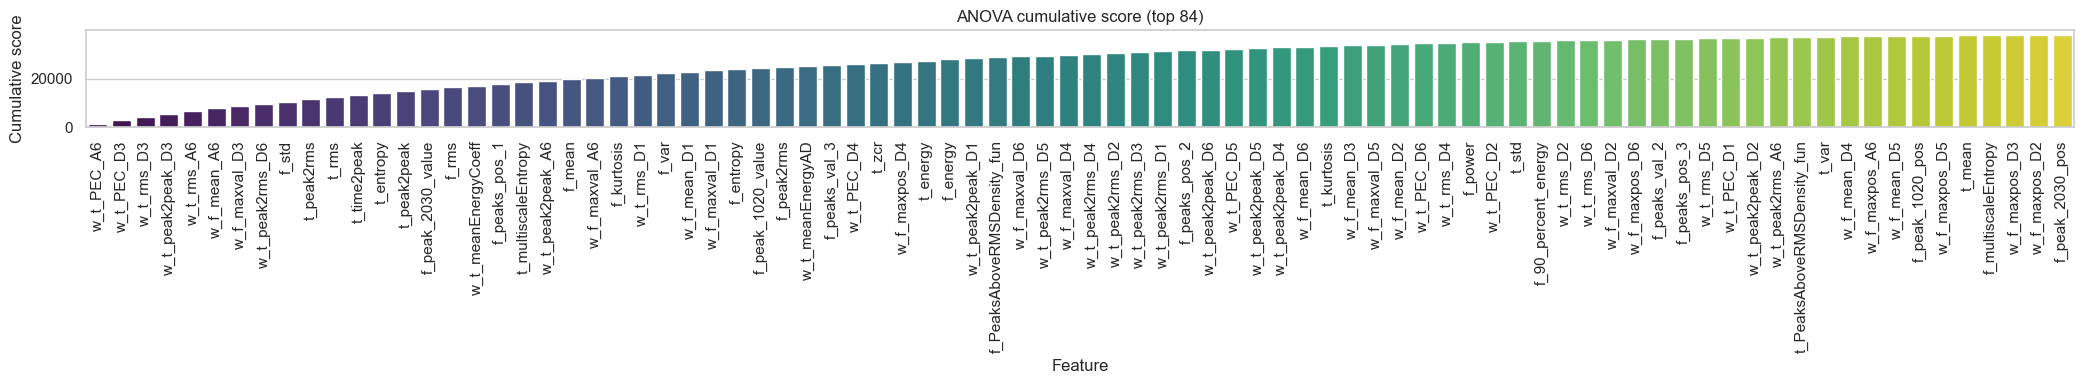

C:\Users\ricar\AppData\Local\Temp\ipykernel_6116\1706119852.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='feature', y='cum_score', palette='viridis')
C:\Users\ricar\AppData\Local\Temp\ipykernel_6116\1706119852.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')


Guardado figura: c:\Users\ricar\OneDrive\Desktop\TESIS\MutualInformation_cumulative_score.png


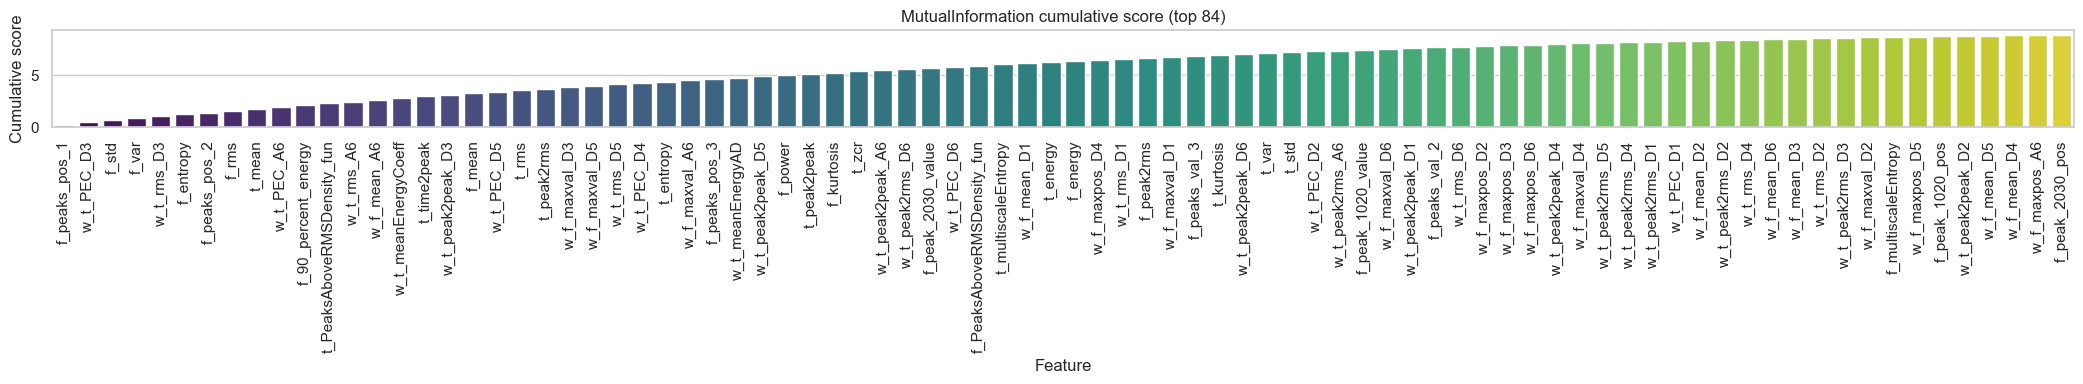

In [13]:
# Plots de score acumulado por método (eje x = feature, eje y = score acumulado)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

output_dir = os.path.join(r'c:\Users\ricar\OneDrive\Desktop\TESIS')

methods = {
    'Variance': X_scaled.var(ddof=0),
    'Laplacian': pd.Series({col: score for col, score in laplacian_scores}),
    'ANOVA': feature_anova.set_index('feature')['F_value'],
    'MutualInformation': feature_mi.set_index('feature')['mi_score'],
}

for name, series in methods.items():
    s = series.dropna().sort_values(ascending=False)
    cum = s.cumsum()
    top_n = min(100, len(cum))
    plot_df = cum.head(top_n).reset_index()
    plot_df.columns = ['feature', 'cum_score']

    plt.figure(figsize=(max(12, top_n*0.25), 4))
    ax = sns.barplot(data=plot_df, x='feature', y='cum_score', palette='viridis')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
    ax.set_title(f'{name} cumulative score (top {top_n})')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Cumulative score')
    plt.tight_layout()

    fig_path = os.path.join(output_dir, f'{name}_cumulative_score.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Guardado figura: {fig_path}')
    plt.show()

Guardado figura: c:\Users\ricar\OneDrive\Desktop\TESIS\Variance_cumulative_pct.png


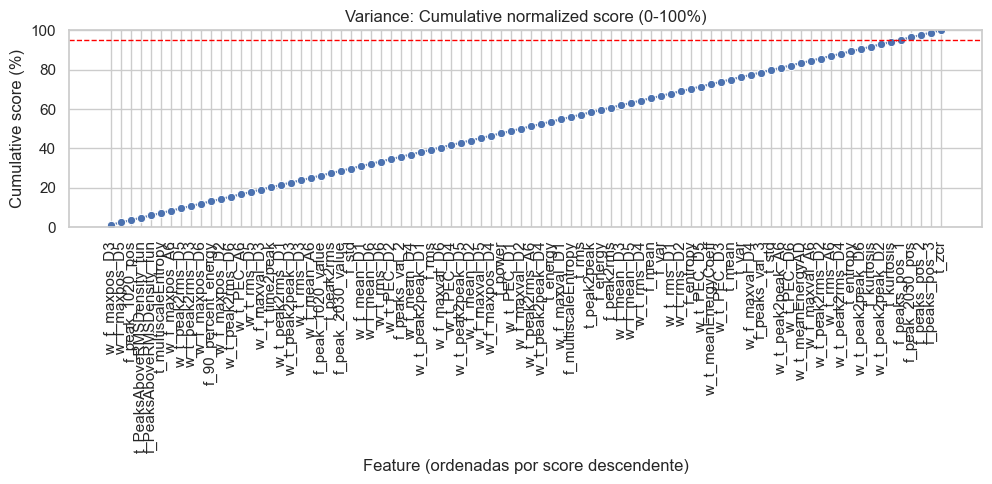

Guardado figura: c:\Users\ricar\OneDrive\Desktop\TESIS\Laplacian_cumulative_pct.png


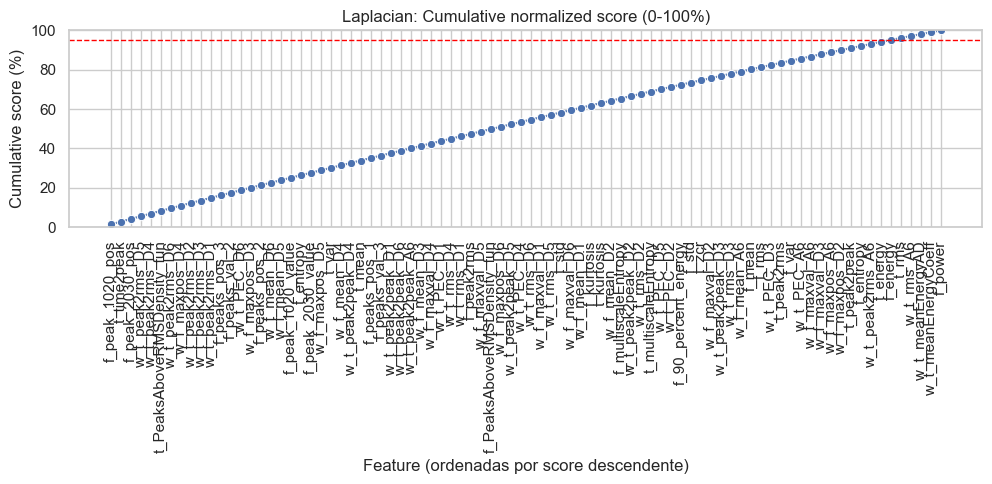

Guardado figura: c:\Users\ricar\OneDrive\Desktop\TESIS\ANOVA_cumulative_pct.png


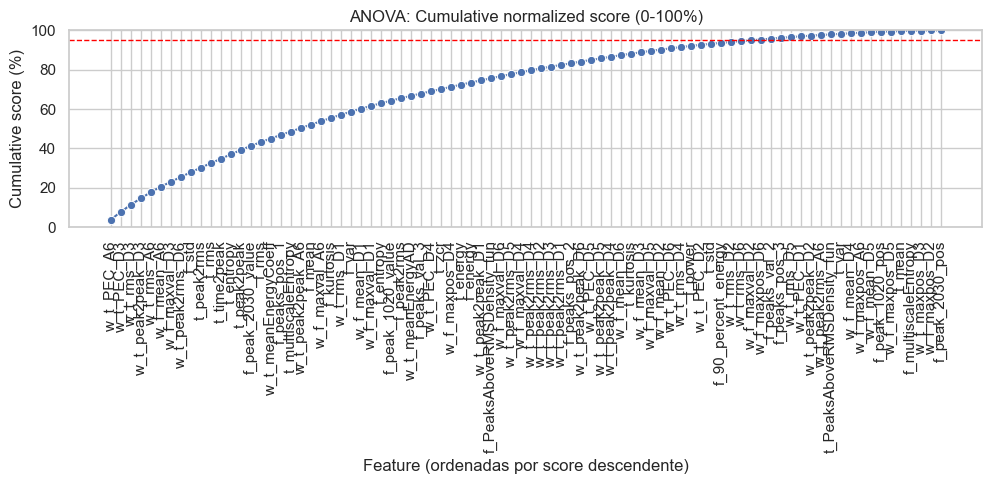

Guardado figura: c:\Users\ricar\OneDrive\Desktop\TESIS\MutualInformation_cumulative_pct.png


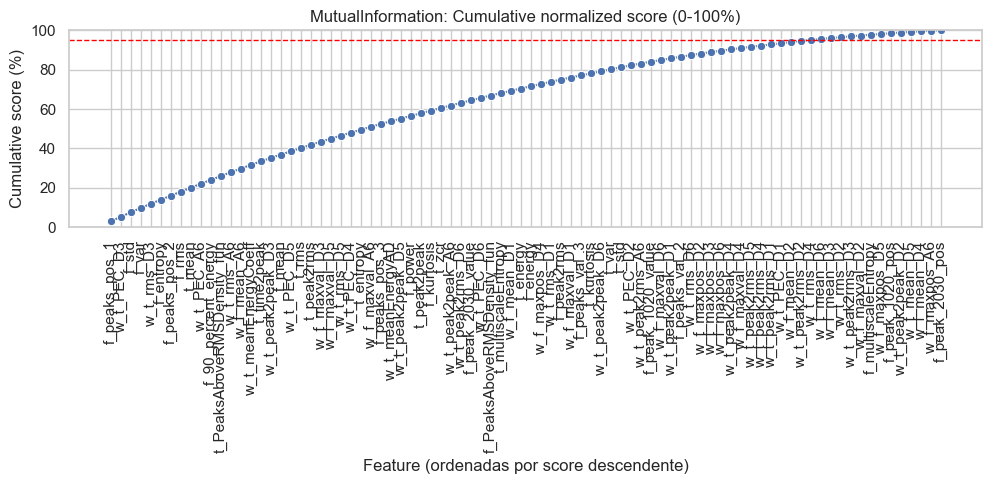

In [14]:
# Gráficos tipo "varianza acumulada" sobre los scores de cada método
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

output_dir = os.path.join(r'c:\Users\ricar\OneDrive\Desktop\TESIS')

methods = {
    'Variance': X_scaled.var(ddof=0),
    'Laplacian': pd.Series({col: score for col, score in laplacian_scores}),
    'ANOVA': feature_anova.set_index('feature')['F_value'],
    'MutualInformation': feature_mi.set_index('feature')['mi_score'],
}

for name, series in methods.items():
    s = series.dropna().sort_values(ascending=False)
    cum_pct = (s.cumsum() / s.sum()) * 100
    plot_df = cum_pct.reset_index()
    plot_df.columns = ['feature', 'cum_pct']

    # Para legibilidad mostramos hasta top_k features en etiquetas (pero la curva incluye todas)
    top_k = min(100, len(plot_df))
    plt.figure(figsize=(max(10, top_k * 0.12), 5))
    ax = sns.lineplot(data=plot_df, x='feature', y='cum_pct', marker='o')
    ax.set_xticks(range(0, top_k))
    ax.set_xticklabels(plot_df['feature'].iloc[:top_k], rotation=90, ha='center')
    ax.set_ylim(0, 100)
    ax.axhline(95, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Feature (ordenadas por score descendente)')
    ax.set_ylabel('Cumulative score (%)')
    ax.set_title(f'{name}: Cumulative normalized score (0-100%)')
    plt.tight_layout()

    fig_path = os.path.join(output_dir, f'{name}_cumulative_pct.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Guardado figura: {fig_path}')
    plt.show()

Guardado figura: c:\Users\ricar\OneDrive\Desktop\TESIS\borda_cumulative_pct.png


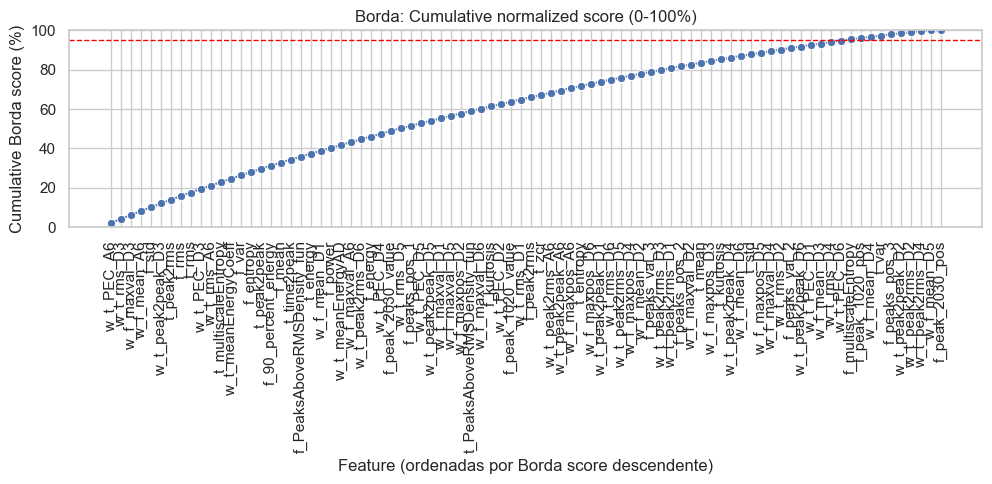

In [15]:
# Gráfico acumulado (PCA-like) usando el Borda score
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# Asegurarnos de tener borda_ranking
if 'borda_ranking' not in globals():
    raise RuntimeError('`borda_ranking` no existe. Ejecuta la celda de Borda voting primero.')

borda_series = borda_ranking.set_index('feature')['borda_score'].sort_values(ascending=False)

cum_pct = (borda_series.cumsum() / borda_series.sum()) * 100
plot_df = cum_pct.reset_index()
plot_df.columns = ['feature', 'cum_pct']

# Mostrar hasta top_k en etiquetas para legibilidad
top_k = min(100, len(plot_df))
plt.figure(figsize=(max(10, top_k * 0.12), 5))
ax = sns.lineplot(data=plot_df, x='feature', y='cum_pct', marker='o')
ax.set_xticks(range(0, top_k))
ax.set_xticklabels(plot_df['feature'].iloc[:top_k], rotation=90, ha='center')
ax.set_ylim(0, 100)
ax.axhline(95, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Feature (ordenadas por Borda score descendente)')
ax.set_ylabel('Cumulative Borda score (%)')
ax.set_title('Borda: Cumulative normalized score (0-100%)')
plt.tight_layout()

fig_path = os.path.join(output_dir, 'borda_cumulative_pct.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Guardado figura: {fig_path}')
plt.show()

In [17]:
# Guardar dataset con top 30 features según Borda voting
# Selecciona las 30 mejores features y el label 'Type'
top30_features = borda_ranking['feature'].head(30).tolist()
print('Top30 selected (Borda):', top30_features)

cols_to_keep = top30_features + [label_col]
missing = [c for c in cols_to_keep if c not in data_model.columns]
if missing:
    raise RuntimeError(f'Algunas columnas no existen en `data_model`: {missing}')

data_model_borda30 = data_model[cols_to_keep].copy().reset_index(drop=True)
print('data_model_borda30 shape:', data_model_borda30.shape)

# Guardar en formatos convenientes para modelado
out_csv = os.path.join(output_dir, 'data_model_borda30.csv')
out_pkl = os.path.join(output_dir, 'data_model_borda30.pkl')

data_model_borda30.to_csv(out_csv, index=False)
data_model_borda30.to_pickle(out_pkl)

print('Guardado data_model_borda30 en:')
print('-', out_csv)
print('-', out_pkl)

Top30 selected (Borda): ['w_t_PEC_A6', 'w_t_rms_D3', 'w_f_maxval_D3', 'w_f_mean_A6', 'f_std', 'w_t_peak2peak_D3', 't_peak2rms', 'f_rms', 't_rms', 'w_t_PEC_D3', 'w_t_rms_A6', 't_multiscaleEntropy', 'w_t_meanEnergyCoeff', 'f_var', 'f_entropy', 't_peak2peak', 'f_90_percent_energy', 'f_mean', 't_time2peak', 'f_PeaksAboveRMSDensity_fun', 't_energy', 'w_f_mean_D1', 'f_power', 'w_t_meanEnergyAD', 'w_f_maxval_A6', 'w_t_peak2rms_D6', 'f_energy', 'w_t_PEC_D4', 'f_peak_2030_value', 'w_t_rms_D5']
data_model_borda30 shape: (23779, 31)
Guardado data_model_borda30 en:
- c:\Users\ricar\OneDrive\Desktop\TESIS\data_model_borda30.csv
- c:\Users\ricar\OneDrive\Desktop\TESIS\data_model_borda30.pkl
